# 10b — Hedged Strategy Attribution: Momentum (2019–2025)

Parallel analysis to NB10 for the EEM-hedged **All6-EW + Momentum** strategy.

In [1]:
import sys, warnings
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import rankdata

from src.data_loader import load_signal_data, FACTOR_COLUMNS, INDUSTRIES, COUNTRY_TC_BPS, DEFAULT_TC_BPS

OUTPUT_DIR = '../output'
HOLD_START = pd.Timestamp('2019-01-01')
REALISTIC_TC_BPS = 45.0

def ann_sharpe(s):
    s = s.dropna()
    if len(s) < 6 or s.std() == 0: return np.nan
    return s.mean()*12 / (s.std()*np.sqrt(12))
def ann_ret(s): return s.dropna().mean() * 12
def ann_vol(s): return s.dropna().std() * np.sqrt(12)
def max_dd(s):
    cum = (1 + s.dropna()).cumprod()
    return float((cum / cum.cummax() - 1).min())
hdf = pd.read_csv(f'{OUTPUT_DIR}/csv/nb09_hedged_returns.csv', index_col=0, parse_dates=True)
ind_ret = pd.read_csv(f'{OUTPUT_DIR}/csv/composite_all6_ew_industry_returns.csv', index_col=0, parse_dates=True)

stock_to = 0.1842; pc_to_mom = 0.0959; total_to_mom = stock_to + pc_to_mom
TC_mom = total_to_mom * (REALISTIC_TC_BPS / 10_000)

hold = hdf[hdf.index >= HOLD_START].copy()
print(f'Holdout: {hold.index[0].strftime("%Y-%m")} to {hold.index[-1].strftime("%Y-%m")} ({len(hold)} months)')

Holdout: 2019-01 to 2025-03 (75 months)


## 1. Hedge Ratio & Residual Exposure

HEDGED MEASURES: Momentum (Net @45bp)
  Jensen's Alpha:     3.35%/yr (t=0.07)
  Residual Beta:       0.055
  R²:                  0.0241
  Appraisal Ratio:     0.516
  Sharpe:              0.565
  Avg hedge beta:      0.900


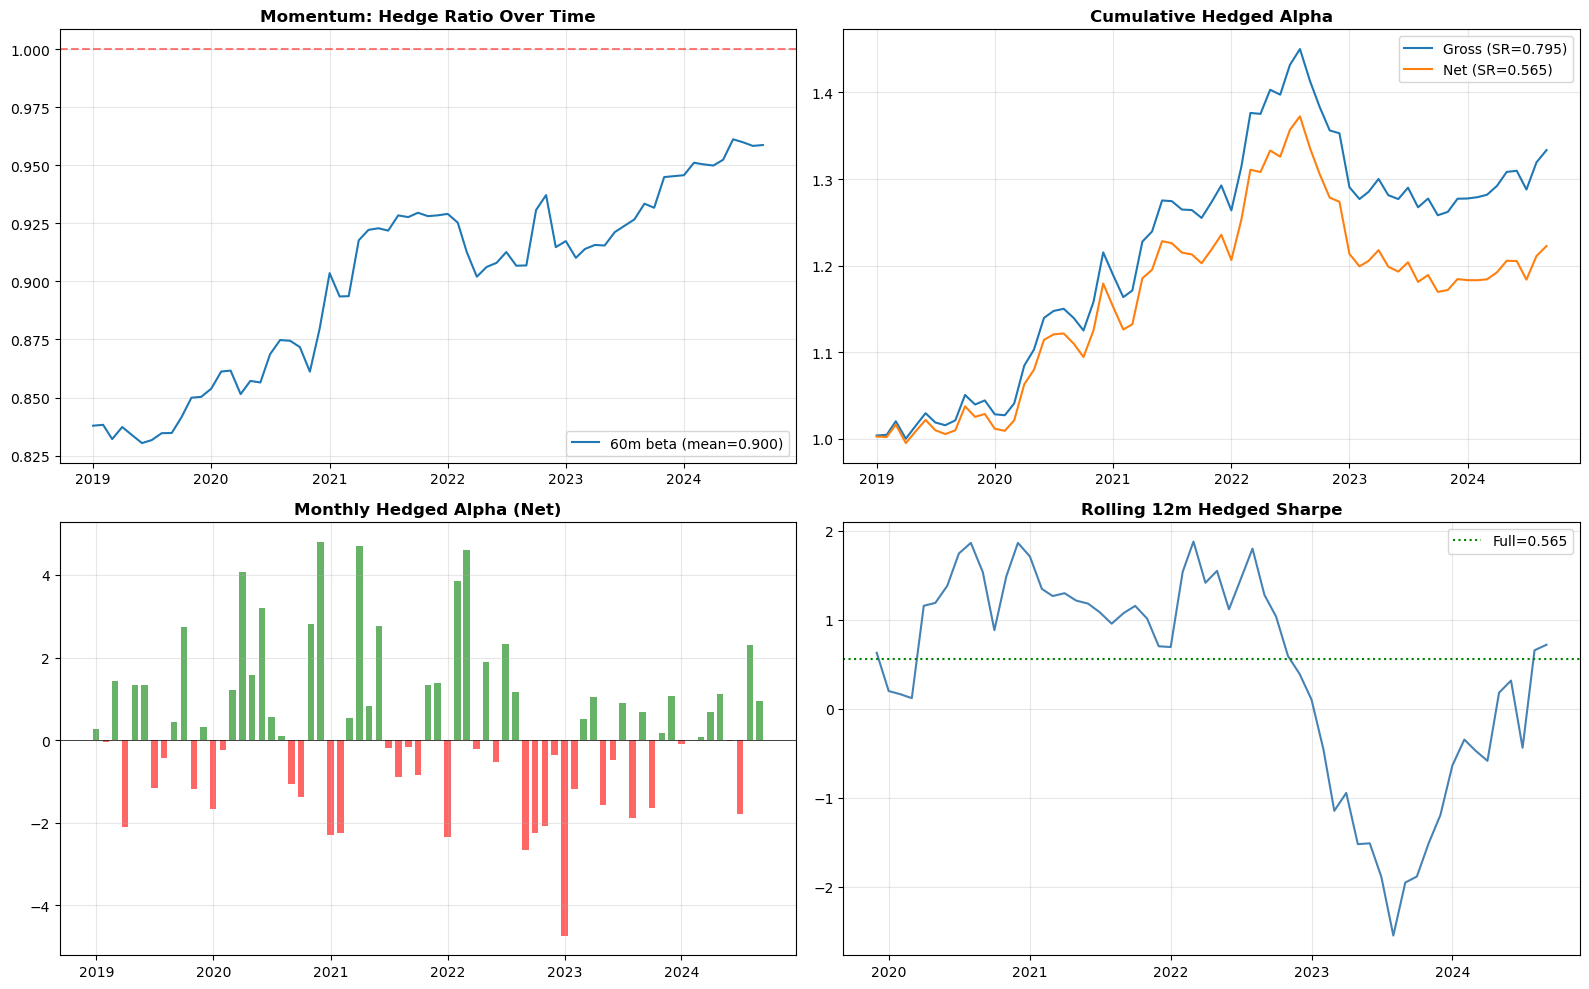

In [2]:
from src.residual_returns import estimate_rolling_beta

lo = hdf['B_long'].dropna()
eem = hdf['EEM_ret'].dropna()
beta_eem_h = hold['B_beta_eem'].dropna()

hedged_h = hold['B_hedged_eem'].dropna()
hedged_net = hedged_h - TC_mom
eem_hold = hold['EEM_ret'].dropna()

aligned = pd.concat([hedged_net.rename('h'), eem_hold.rename('m')], axis=1).dropna()
slope, intercept, r_val, p_val, se = stats.linregress(aligned['m'], aligned['h'])
s_p = np.std(aligned['h'].values - (intercept + slope * aligned['m'].values), ddof=1) * np.sqrt(12)

print('HEDGED MEASURES: Momentum (Net @45bp)')
print('='*60)
print(f'  Jensen\'s Alpha:     {intercept*12:.2%}/yr (t={intercept/se:.2f})')
print(f'  Residual Beta:       {slope:.3f}')
print(f'  R²:                  {r_val**2:.4f}')
print(f'  Appraisal Ratio:     {intercept*12/s_p:.3f}')
print(f'  Sharpe:              {ann_sharpe(hedged_net):.3f}')
print(f'  Avg hedge beta:      {beta_eem_h.mean():.3f}')

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

ax = axes[0, 0]
ax.plot(beta_eem_h.index, beta_eem_h.values, lw=1.5, label=f'60m beta (mean={beta_eem_h.mean():.3f})')
ax.axhline(y=1, color='red', ls='--', alpha=0.5)
ax.set_title('Momentum: Hedge Ratio Over Time', fontweight='bold'); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[0, 1]
cum_g = (1+hedged_h).cumprod()
cum_n = (1+hedged_net).cumprod()
ax.plot(cum_g.index, cum_g, lw=1.5, label=f'Gross (SR={ann_sharpe(hedged_h):.3f})')
ax.plot(cum_n.index, cum_n, lw=1.5, label=f'Net (SR={ann_sharpe(hedged_net):.3f})')
ax.set_title('Cumulative Hedged Alpha', fontweight='bold'); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1, 0]
colors = ['green' if x>0 else 'red' for x in hedged_net.values]
ax.bar(hedged_net.index, hedged_net.values*100, color=colors, alpha=0.6, width=20)
ax.axhline(y=0, color='k', lw=0.5)
ax.set_title('Monthly Hedged Alpha (Net)', fontweight='bold'); ax.grid(True, alpha=0.3)

ax = axes[1, 1]
roll_sr = hedged_net.rolling(12).apply(lambda x: x.mean()*12/(x.std()*np.sqrt(12)) if x.std()>0 else 0)
ax.plot(roll_sr.index, roll_sr, lw=1.5, color='steelblue')
ax.axhline(y=ann_sharpe(hedged_net), color='green', ls=':', label=f'Full={ann_sharpe(hedged_net):.3f}')
ax.set_title('Rolling 12m Hedged Sharpe', fontweight='bold'); ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.savefig(f'{OUTPUT_DIR}/figures/nb10b_hedge_dynamics.pdf', bbox_inches='tight'); plt.show()

## 2. Sub-Period Stability

ANNUAL HEDGED PERFORMANCE (Momentum, Net @45bp)
      Alpha  Sharpe  Hit Rate   Vol  MaxDD   N
Year                                          
2019  0.029   0.630     0.583 0.047 -0.021  12
2020  0.146   1.866     0.667 0.075 -0.024  12
2021  0.048   0.704     0.500 0.069 -0.022  12
2022  0.031   0.393     0.417 0.086 -0.072  12
2023 -0.070  -1.193     0.500 0.059 -0.040  12
2024  0.032   1.112     0.556 0.039 -0.018   9


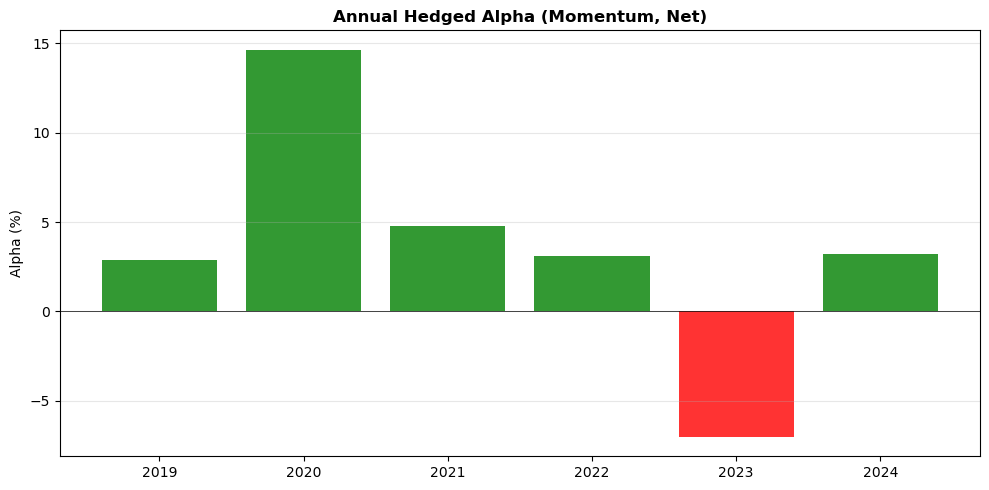

In [3]:
rows = []
for yr, g in hedged_net.groupby(hedged_net.index.year):
    rows.append({'Year': yr, 'Alpha': (1+g).prod()-1, 'Sharpe': ann_sharpe(g) if len(g)>=6 else np.nan,
                 'Hit Rate': (g>0).mean(), 'Vol': g.std()*np.sqrt(12), 'MaxDD': max_dd(g), 'N': int(len(g))})
annual = pd.DataFrame(rows).set_index('Year')
print('ANNUAL HEDGED PERFORMANCE (Momentum, Net @45bp)')
print(annual.to_string(float_format=lambda x: f'{x:.3f}' if abs(x)<2 else f'{x:.0f}'))

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['green' if x>0 else 'red' for x in annual['Alpha']]
ax.bar(annual.index.astype(int), annual['Alpha']*100, color=colors, alpha=0.8)
ax.axhline(y=0, color='k', lw=0.5)
ax.set_title('Annual Hedged Alpha (Momentum, Net)', fontweight='bold')
ax.set_ylabel('Alpha (%)'); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout(); plt.savefig(f'{OUTPUT_DIR}/figures/nb10b_subperiod.pdf', bbox_inches='tight'); plt.show()

## 3. Summary Comparison with TO\_MVO

In [4]:
lo_a = hdf['A_long'].dropna(); lo_b = hdf['B_long'].dropna()
hd_a = hdf['A_hedged_eem'].dropna(); hd_b = hdf['B_hedged_eem'].dropna()
tc_a = 0.1916 * (45/10000); tc_b = total_to_mom * (45/10000)

metrics = pd.DataFrame({
    'TO_MVO': {
        'LO Gross SR': ann_sharpe(lo_a[lo_a.index>=HOLD_START]),
        'LO Net SR': ann_sharpe(lo_a[lo_a.index>=HOLD_START] - tc_a),
        'Hedged Gross SR': ann_sharpe(hd_a[hd_a.index>=HOLD_START]),
        'Hedged Net SR': ann_sharpe(hd_a[hd_a.index>=HOLD_START] - tc_a),
        'Monthly TO': 0.1916,
        'TC drag (ann)': tc_a * 12,
    },
    'Momentum': {
        'LO Gross SR': ann_sharpe(lo_b[lo_b.index>=HOLD_START]),
        'LO Net SR': ann_sharpe(lo_b[lo_b.index>=HOLD_START] - tc_b),
        'Hedged Gross SR': ann_sharpe(hd_b[hd_b.index>=HOLD_START]),
        'Hedged Net SR': ann_sharpe(hd_b[hd_b.index>=HOLD_START] - tc_b),
        'Monthly TO': total_to_mom,
        'TC drag (ann)': tc_b * 12,
    }
})
print('HEAD-TO-HEAD COMPARISON')
print('='*60)
print(metrics.to_string(float_format=lambda x: f'{x:.3f}'))
print(f'\nMomentum advantage (gross hedged): {metrics.loc["Hedged Gross SR","Momentum"]-metrics.loc["Hedged Gross SR","TO_MVO"]:.3f}')
print(f'TO_MVO advantage (net hedged):     {metrics.loc["Hedged Net SR","TO_MVO"]-metrics.loc["Hedged Net SR","Momentum"]:.3f}')

HEAD-TO-HEAD COMPARISON
                 TO_MVO  Momentum
LO Gross SR       0.514     0.503
LO Net SR         0.458     0.421
Hedged Gross SR   0.828     0.795
Hedged Net SR     0.673     0.565
Monthly TO        0.192     0.280
TC drag (ann)     0.010     0.015

Momentum advantage (gross hedged): -0.033
TO_MVO advantage (net hedged):     0.108
